<h1 align="center">
 Exploratory Data Analysis (EDA)
</h1>


### Task 1: Temporal Distribution Analysis

 <b>Objective:</b>  Analyze earthquake frequency and magnitude trends over time.
 
<b> Tasks: </b>
- Plot earthquake frequency by Year, Month, and DayOfWeek
- Identify seasonal patterns and temporal trends
- Calculate mean magnitude and damage potential by temporal dimensions
- Visualize time series of earthquake counts and average magnitude over years
- Create heatmap of earthquakes by Month and DayOfWeek


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data = pd.read_csv("../Day_13/preprocessed_earthquake_data.csv")
data['Mw'] = data['Mw'].fillna(data['Mw'].mean())
min(data['depth']), max(data['depth'])


(-0.607032439010643, 5.933335577547115)

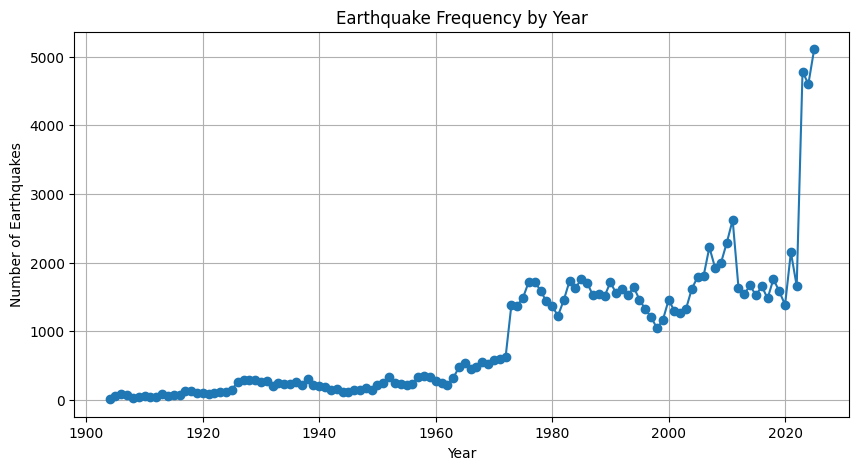

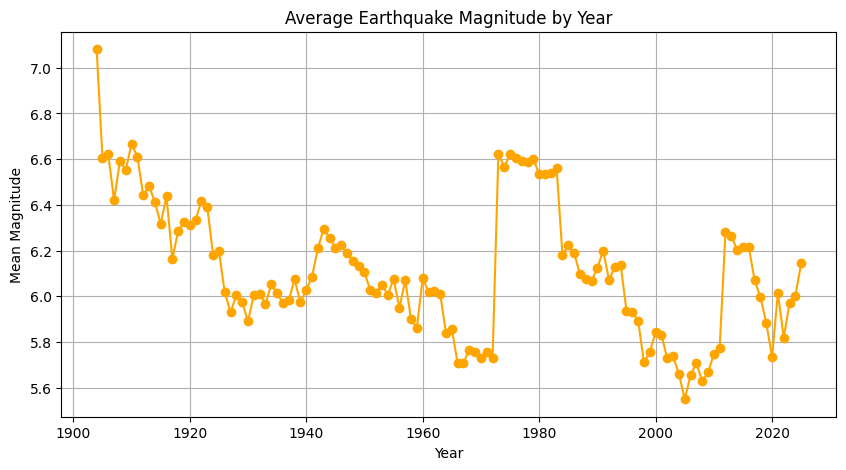

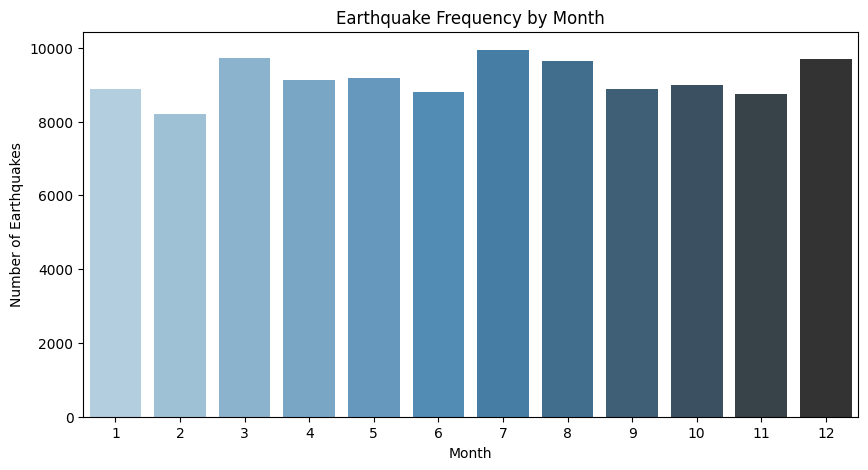

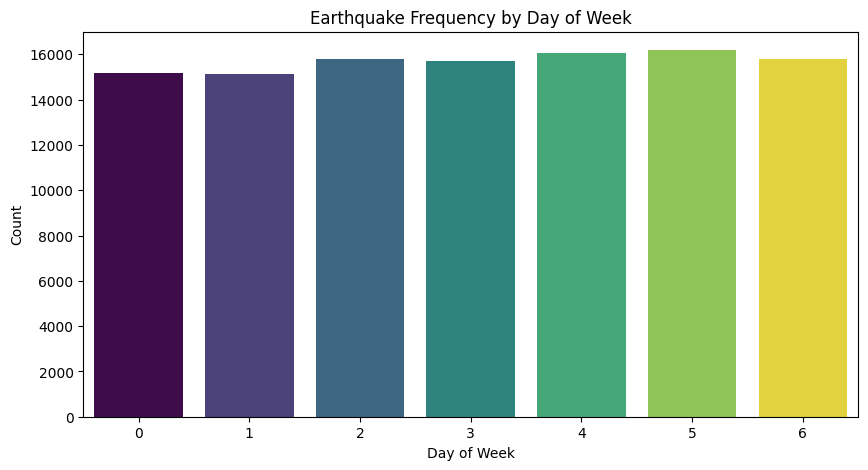

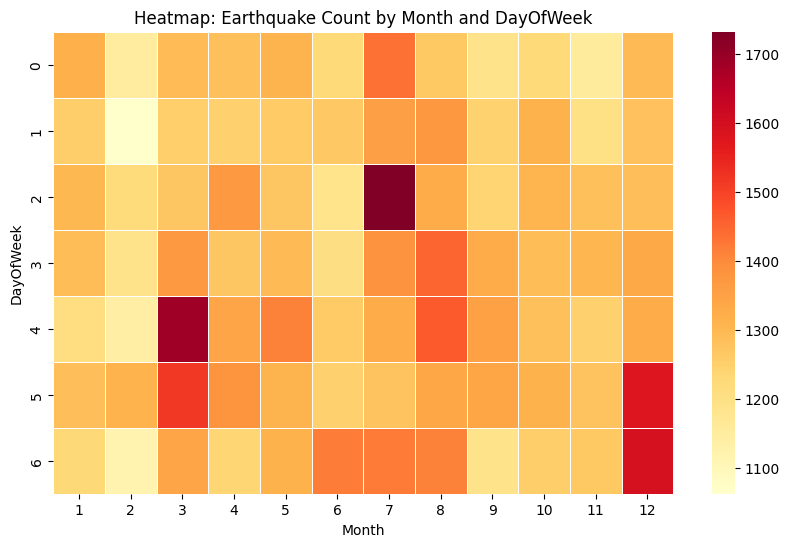


===== SUMMARY STATISTICS =====
Total Events: 109848
Years Covered: 1904 - 2025
Mean Magnitude: 6.06
Median Magnitude: 6.13
Mean Damage Potential: 9.5


In [2]:
# --- Yearly analysis ---
yearly = data.groupby('Year').agg(
    frequency=('Year', 'count'),
    mean_magnitude=('Mw', 'mean'),
    mean_damage=('damage_potential', 'mean')
).reset_index()


# --- Monthly analysis ---
monthly = data.groupby('Month').agg(
    frequency=('Month', 'count'),
    mean_magnitude=('Mw', 'mean'),
    mean_damage=('damage_potential', 'mean')
).reset_index()

# --- Day of Week analysis ---
weekday = data.groupby('DayOfWeek').agg(
    frequency=('DayOfWeek', 'count'),
    mean_magnitude=('Mw', 'mean'),
    mean_damage=('damage_potential', 'mean')
).reindex([0,1,2,3,4,5,6]).reset_index()

# =================== Visualization Section =================== #

# 1. Earthquake frequency over years
plt.figure(figsize=(10,5))
plt.plot(yearly['Year'], yearly['frequency'], marker='o')
plt.title("Earthquake Frequency by Year")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.grid(True)
plt.show()

# 2. Mean Magnitude over Years
plt.figure(figsize=(10,5))
plt.plot(yearly['Year'], yearly['mean_magnitude'], color='orange', marker='o')
plt.title("Average Earthquake Magnitude by Year")
plt.xlabel("Year")
plt.ylabel("Mean Magnitude")
plt.grid(True)
plt.show()


# 3. Monthly frequency
plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='frequency', hue='Month', data=monthly, palette='Blues_d', legend=False)
plt.title("Earthquake Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Number of Earthquakes")
plt.show()


# 4. Day of Week frequency
plt.figure(figsize=(10,5))
sns.barplot(x='DayOfWeek', y='frequency', hue='DayOfWeek', data=weekday, palette='viridis', legend=False)
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()


# 5. Heatmap of Month vs Day of Week
heatmap_data = data.pivot_table(index='DayOfWeek', columns='Month', values='Mw', aggfunc='count').fillna(0)
heatmap_data = heatmap_data.reindex([0, 1, 2, 3, 4, 5, 6])
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap: Earthquake Count by Month and DayOfWeek')
plt.xlabel('Month')
plt.ylabel('DayOfWeek')
plt.show()

# --- Summary ---
summary = {
    'Total Events': len(data),
    'Years Covered': f"{data['Year'].min()} - {data['Year'].max()}",
    'Mean Magnitude': round(data['Mw'].mean(), 2),
    'Median Magnitude': round(data['Mw'].median(), 2),
    'Mean Damage Potential': round(data['damage_potential'].mean(), 2)
}

print("\n===== SUMMARY STATISTICS =====")
for k, v in summary.items():
    print(f"{k}: {v}")


### Task 2: Geographical Distribution Analysis

 <b>Objective:</b>  Explore spatial patterns of earthquake epicenters.
 
<b> Tasks: </b>
- Generate scatter plot of latitude vs. longitude colored by magnitude or damage_potential
- Create density maps or 2D histograms showing earthquake hotspots
- Analyze earthquake distribution by geographical regions (latitude/longitude bins)
- Calculate correlation between geographical coordinates and seismic characteristics
- Identify high-risk geographical areas based on damage_potential


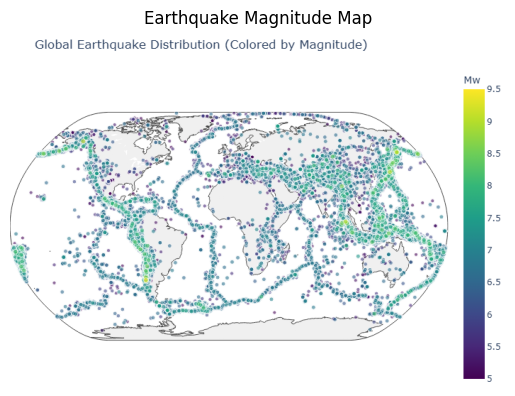

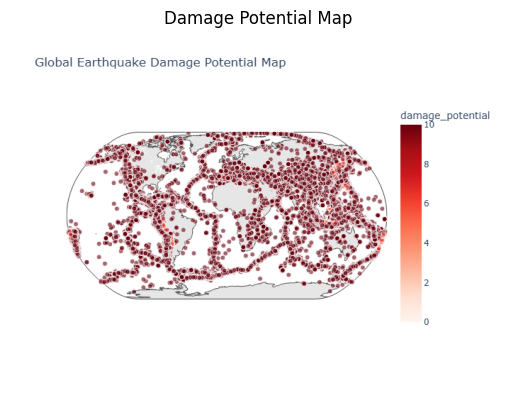

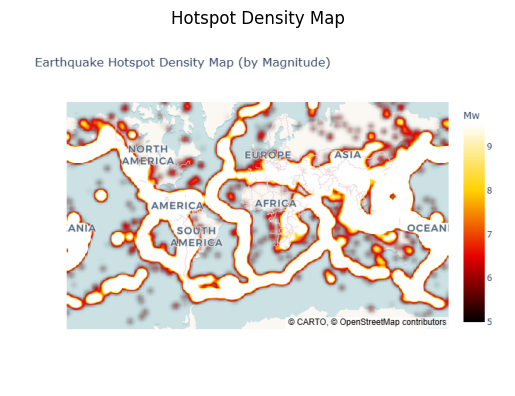

Number of high-risk points: 91413


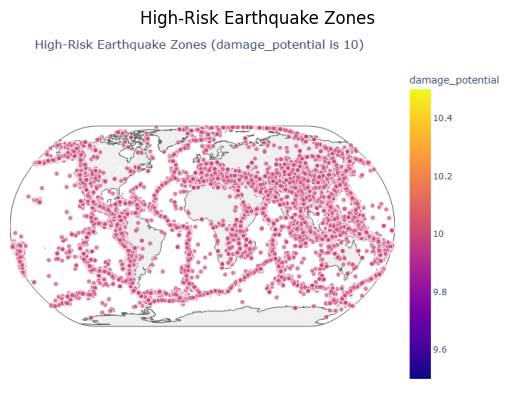

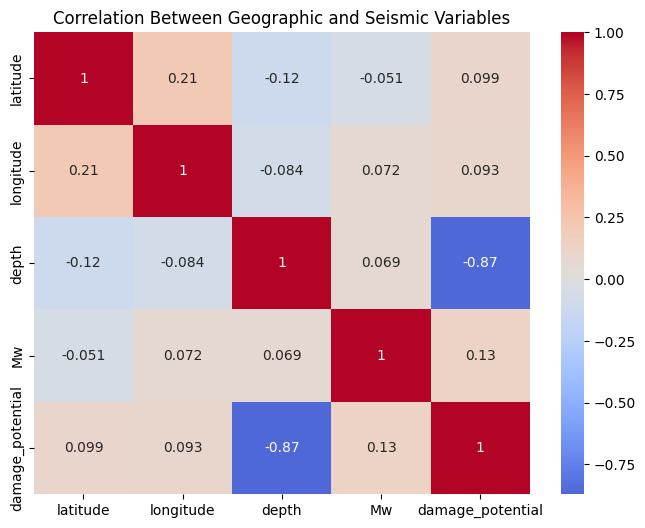

In [3]:
import plotly.express as px
import matplotlib.image as mpimg

data = data.sort_values(by='Mw', ascending=True)

# 1️ Earthquake Locations Colored by Magnitude

fig1 = px.scatter_geo(
    data,
    lat='latitude',
    lon='longitude',
    color='Mw',
    size='Mw',
    opacity=0.6,
    size_max=5,
    projection='natural earth',
    color_continuous_scale='Viridis',
    hover_name='type',
    title='Global Earthquake Distribution (Colored by Magnitude)'
)
fig1.update_layout(
    geo=dict(showland=True, landcolor="rgb(240, 240, 240)"),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig1.write_image("earthquake_map.png")

img = mpimg.imread("earthquake_map.png")
plt.imshow(img)
plt.axis('off')
plt.title("Earthquake Magnitude Map")
plt.show()

# 2️ Earthquake Locations Colored by Damage Potential

fig2 = px.scatter_geo(
    data,
    lat='latitude',
    lon='longitude',
    color='damage_potential',
    size=data['damage_potential'],
    size_max=5,
    hover_name='type',
    projection='natural earth',
    color_continuous_scale='Reds',
    title='Global Earthquake Damage Potential Map',
    opacity=0.6
)
fig2.update_layout(geo=dict(showland=True, landcolor="rgb(230, 230, 230)"))
fig2.write_image("earthquake_damage_map.png")

img = mpimg.imread("earthquake_damage_map.png")
plt.imshow(img)
plt.axis('off')
plt.title("Damage Potential Map")
plt.show()


# 3️ 2D Density (Hotspot Map)

fig3 = px.density_map(
    data,
    lat='latitude',
    lon='longitude',
    z='Mw',
    radius=10,
    center=dict(lat=0, lon=0),
    zoom=0,
    
    color_continuous_scale="Hot",
    title='Earthquake Hotspot Density Map (by Magnitude)'
)
fig3.write_image("earthquake_hotspot_map.png")

img = mpimg.imread("earthquake_hotspot_map.png")
plt.imshow(img)
plt.axis('off')
plt.title("Hotspot Density Map")
plt.show()


# 4 High-Risk Areas (damage_potential is 10)

high_risk = data[data['damage_potential'] == 10]

# Check if you actually have points
print(f"Number of high-risk points: {len(high_risk)}")


fig4 = px.scatter_geo(
    high_risk,
    lat='latitude',
    lon='longitude',
    color='damage_potential',
    size=high_risk['damage_potential'],
    size_max=5,
    hover_name='type',
    projection='natural earth',
    title='High-Risk Earthquake Zones (damage_potential is 10)',
    opacity=0.7
)
fig4.update_layout(
    geo=dict(showland=True, landcolor="rgb(240,240,240)"),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig4.write_image("earthquake_highrisk_map.png")

img = mpimg.imread("earthquake_highrisk_map.png")
plt.imshow(img)
plt.axis('off')
plt.title("High-Risk Earthquake Zones")
plt.show()


# 5️ Correlation Analysis
cols = ['latitude', 'longitude', 'depth', 'Mw', 'damage_potential']
corr_matrix = data[cols].corr(method='pearson')
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Geographic and Seismic Variables')
plt.show()



### Task 3: Magnitude and Damage Potential Relationship

 <b>Objective:</b>   Analyze the relationship between earthquake magnitude and damage potential.
 
<b> Tasks: </b>
- Create scatter plot: Magnitude (mag) vs. Damage Potential with depth color-coding
- Plot Moment Magnitude (Mw) vs. Damage Potential
- Generate distribution histograms for mag, Mw, and damage_potential (with KDE)
- Calculate correlation coe cients (Pearson and Spearman) between mag/Mw and damage_potential
- Analyze outliers and their characteristics



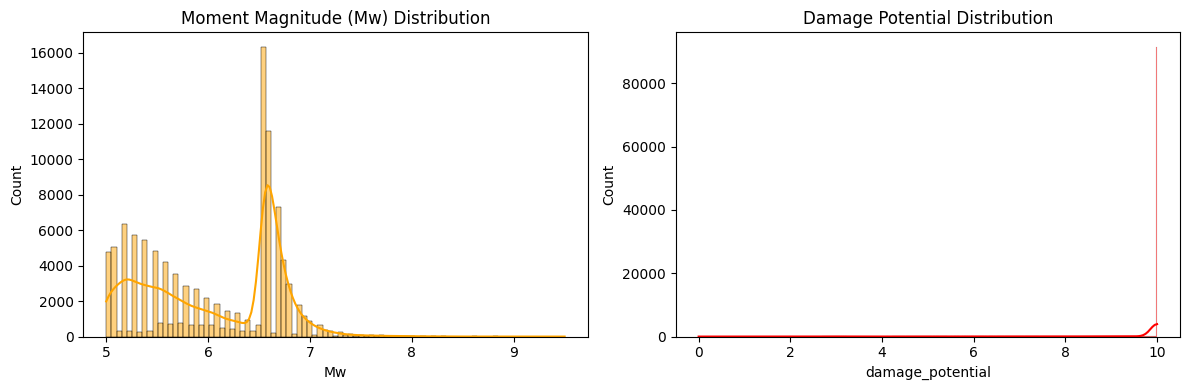

Pearson correlation (Mw vs damage): 0.127
Spearman correlation (Mw vs damage): 0.166
Number of outliers: 0
Empty DataFrame
Columns: [latitude, longitude, Mw, depth, damage_potential]
Index: []


In [4]:
# Scatter plot using Plotly for interactivity
fig1 = px.scatter(
    data,
    x='Mw',
    y='damage_potential',
    color='depth',
    color_continuous_scale='Viridis',
    title='Magnitude vs Damage Potential (Colored by Depth)',
    labels={'Mw': 'Magnitude', 'damage_potential': 'Damage Potential', 'depth': 'Depth (km)'},
    opacity=0.7
)
fig1.show()


# Moment Magnitude (Mw) Distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data['Mw'], kde=True, color='orange')
plt.title('Moment Magnitude (Mw) Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data['damage_potential'], kde=True, color='red')
plt.title('Damage Potential Distribution')

plt.tight_layout()
plt.show()


from scipy.stats import pearsonr, spearmanr

# Pearson (linear correlation)
pearson_Mw, _ = pearsonr(data['Mw'], data['damage_potential'])

# Spearman (rank correlation)
spearman_Mw, _ = spearmanr(data['Mw'], data['damage_potential'])




print(f"Pearson correlation (Mw vs damage): {pearson_Mw:.3f}")
print(f"Spearman correlation (Mw vs damage): {spearman_Mw:.3f}")

# Define outliers as top 5% of damage potential
threshold = data['damage_potential'].quantile(0.95)
outliers = data[data['damage_potential'] > threshold]

print(f"Number of outliers: {len(outliers)}")
print(outliers[['latitude', 'longitude', 'Mw', 'depth', 'damage_potential']].head())




### Task 4:  Depth Analysis and Its Impact

 <b>Objective:</b>    Investigate how depth in uences seismic characteristics and damage.
 
<b> Tasks: </b>
- Create box plots: Depth vs. Magnitude (strati ed by depth ranges: shallow, intermediate, deep)
- Analyze depth distribution with histogram and statistics (mean, median, std)
- Plot depth vs. damage_potential using scatter and 2D density plots
- Calculate mean damage_potential for different depth ranges
- Identify whether shallow or deep earthquakes cause more damage




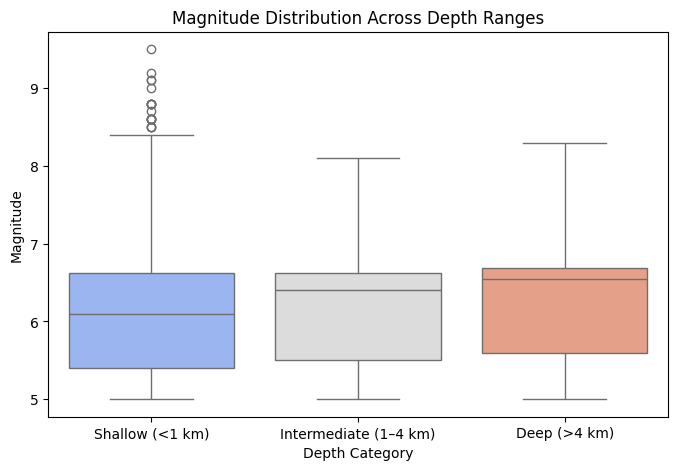

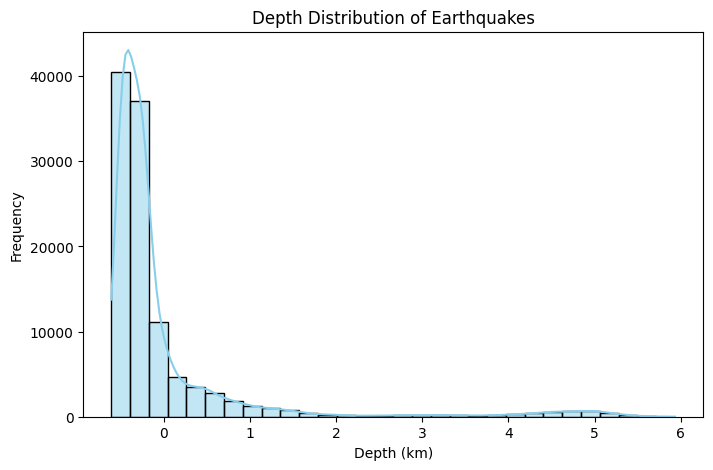

Mean Depth: -0.00 km
Median Depth: -0.26 km
Standard Deviation: 1.00 km


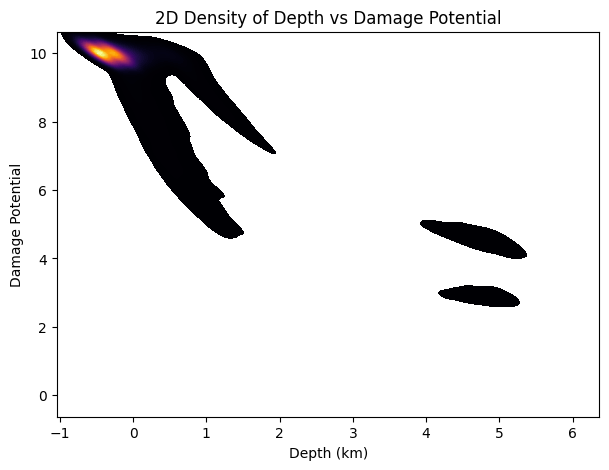

             depth_range  damage_potential
0           Deep (>4 km)          4.033220
1  Intermediate (1–4 km)          6.242715
2        Shallow (<1 km)          9.822651


In [5]:
# Depth categories
def depth_category(depth):
    if depth < 1:
        return 'Shallow (<1 km)'
    elif depth < 4:
        return 'Intermediate (1–4 km)'
    else:
        return 'Deep (>4 km)'

data['depth_range'] = data['depth'].apply(depth_category)

plt.figure(figsize=(8,5))
sns.boxplot(x='depth_range', y='Mw', data=data,hue='depth_range',legend=False, palette='coolwarm')
plt.title('Magnitude Distribution Across Depth Ranges')
plt.xlabel('Depth Category')
plt.ylabel('Magnitude')
plt.show()



plt.figure(figsize=(8,5))
sns.histplot(data['depth'], bins=30, kde=True, color='skyblue')
plt.title('Depth Distribution of Earthquakes')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')
plt.show()

# Statistics
mean_depth = data['depth'].mean()
median_depth = data['depth'].median()
std_depth = data['depth'].std()

print(f"Mean Depth: {mean_depth:.2f} km")
print(f"Median Depth: {median_depth:.2f} km")
print(f"Standard Deviation: {std_depth:.2f} km")


# Scatter
fig1 = px.scatter(
    data,
    x='depth',
    y='damage_potential',
    color='Mw',
    color_continuous_scale='Plasma',
    title='Depth vs Damage Potential (Colored by Magnitude)',
    labels={'depth':'Depth (km)', 'damage_potential':'Damage Potential'}
)
fig1.show()

# 2D Density Plot
plt.figure(figsize=(7,5))
sns.kdeplot(
    x=data['depth'],
    y=data['damage_potential'],
    fill=True,
    cmap='inferno',
    thresh=0.05,
    levels=100
)
plt.title('2D Density of Depth vs Damage Potential')
plt.xlabel('Depth (km)')
plt.ylabel('Damage Potential')
plt.show()



mean_damage = data.groupby('depth_range')['damage_potential'].mean().reset_index()
print(mean_damage)




### Task 5:  Categorical Feature Analysis

 <b>Objective:</b>     Explore relationships between earthquake types, magnitude types, and status.
 
<b> Tasks: </b>
- Analyze value counts for magType, type, and status columns
- Create bar charts showing frequency distribution of each categorical variable
- Generate grouped bar charts: magType vs. mean magnitude and damage_potential
- Create cross-tabulation (contingency tables) between categorical variables
- Visualize earthquake type distribution and its association with damage_potential
- Calculate Cramér's V statistics for categorical associations





magType value counts:
 magType
mb            45084
mw            24335
mwc           17458
mww           15652
ms             3157
mwb            3082
ml              485
mwr             451
md               50
mh               23
m                21
Mi               12
mwp               9
uk                8
fa                5
ml(texnet)        4
ms_20             3
mc                2
Ml                1
mlg               1
mb_lg             1
lg                1
Md                1
ma                1
Mb                1
Name: count, dtype: int64

type value counts:
 type
earthquake           109356
nuclear explosion       424
volcanic eruption        54
explosion                10
landslide                 2
mine collapse             1
rock burst                1
Name: count, dtype: int64

status value counts:
 status
reviewed     109744
automatic       104
Name: count, dtype: int64


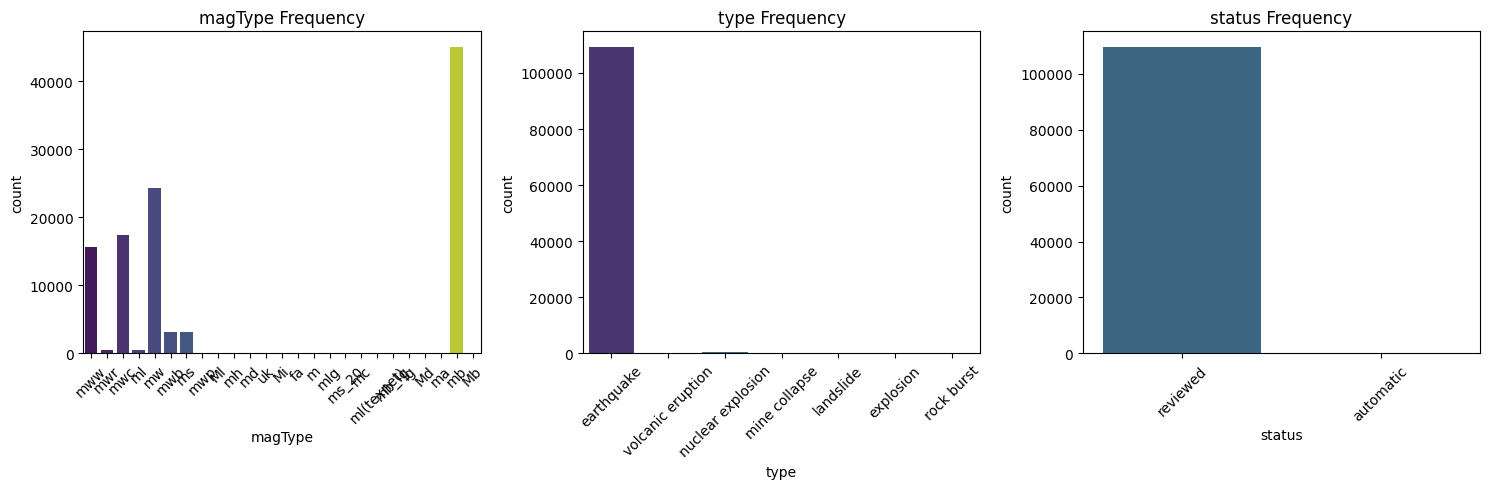

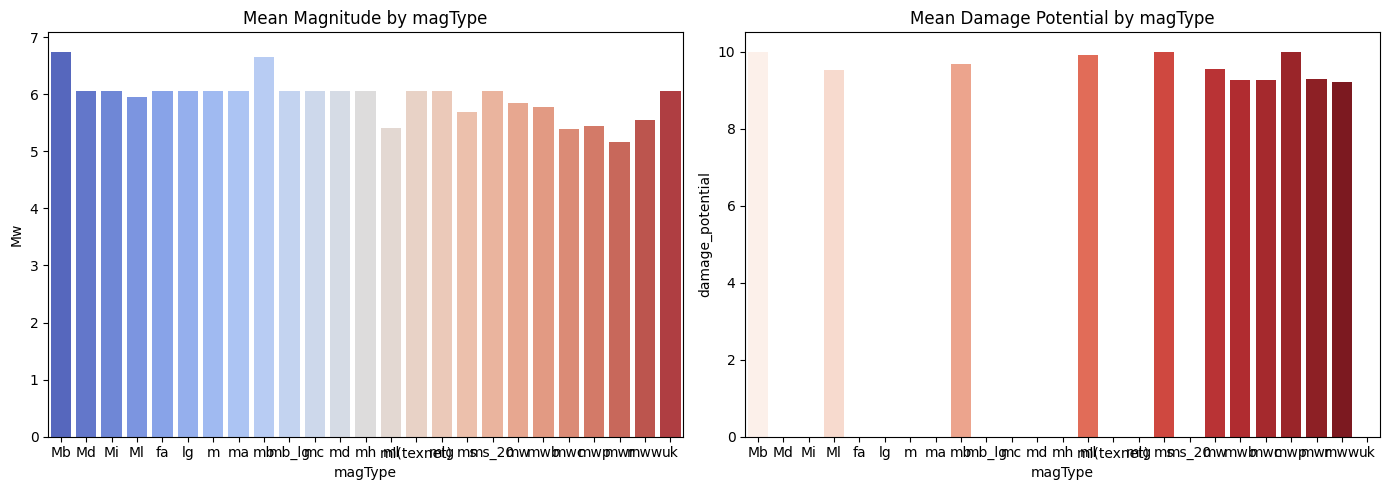


Cross-tab between magType and type:
 type        earthquake  explosion  landslide  mine collapse  \
magType                                                       
Mb                   1          0          0              0   
Md                   1          0          0              0   
Mi                  12          0          0              0   
Ml                   1          0          0              0   
fa                   5          0          0              0   
lg                   1          0          0              0   
m                   21          0          0              0   
ma                   1          0          0              0   
mb               44669         10          0              0   
mb_lg                1          0          0              0   
mc                   2          0          0              0   
md                  50          0          0              0   
mh                  23          0          0              0   
ml               

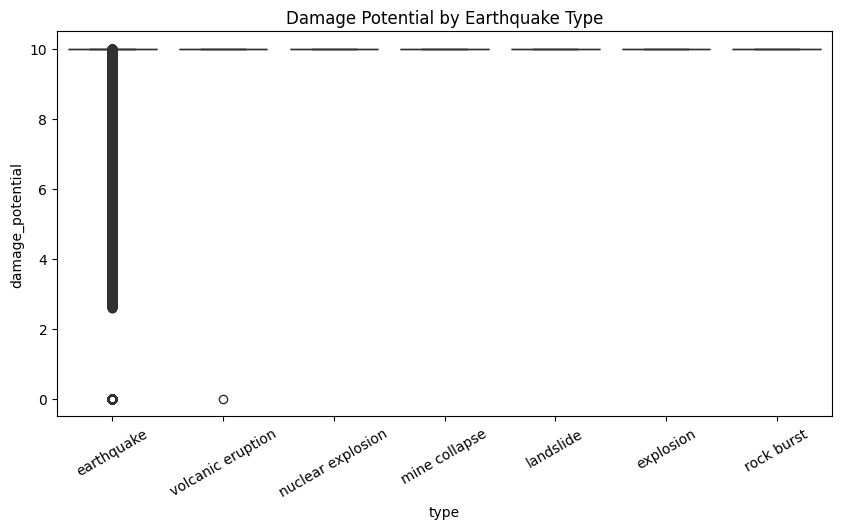

Cramér’s V between magType and type: 0.050
Cramér’s V between status and type: 0.000


In [6]:
from scipy.stats import chi2_contingency

# 1️ Value counts for categorical columns
categorical_cols = ['magType', 'type', 'status']
for col in categorical_cols:
    print(f"\n{col} value counts:\n", data[col].value_counts())

# 2️ Bar charts of frequency distribution

plt.figure(figsize=(15,5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=data, x=col, hue=col, legend=False, palette='viridis')
    plt.title(f"{col} Frequency")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3️ Grouped bar: magType vs mean magnitude and damage potential
grouped = data.groupby('magType')[['Mw', 'damage_potential']].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=grouped, x='magType', y='Mw', hue='magType', palette='coolwarm', legend=False, ax=ax[0])
ax[0].set_title('Mean Magnitude by magType')

sns.barplot(data=grouped, x='magType', y='damage_potential', hue='magType', palette='Reds', legend=False, ax=ax[1])
ax[1].set_title('Mean Damage Potential by magType')

plt.tight_layout()
plt.show()


# 4️ Cross-tabulation (Contingency tables)

for col in ['magType', 'type', 'status']:
    ctab = pd.crosstab(data[col], data['type'])
    print(f"\nCross-tab between {col} and type:\n", ctab)


# 5️ Visualize earthquake type vs damage potential

plt.figure(figsize=(10,5))
sns.boxplot(data=data, x='type', y='damage_potential', hue='type', palette='plasma', legend=False)
plt.title('Damage Potential by Earthquake Type')
plt.xticks(rotation=30)
plt.show()


# 6️ Calculate Cramér’s V (categorical association)
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in ['magType', 'status']:
    v = cramers_v(data[col], data['type'])
    print(f"Cramér’s V between {col} and type: {v:.3f}")
